In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/weather/hcm_weather_2025.csv")

print(df.shape)
df.head()

(8760, 11)


,date,hour,location_name,lat,lon,temperature_2m,relative_humidity_2m,precipitation,rain,wind_speed_10m,cloud_cover
0,2025-01-01,00:00,Ho_Chi_Minh,10.8231,106.6297,23.9,75,0.0,0.0,9.4,100
1,2025-01-01,01:00,Ho_Chi_Minh,10.8231,106.6297,23.2,77,0.0,0.0,9.4,100
2,2025-01-01,02:00,Ho_Chi_Minh,10.8231,106.6297,22.8,78,0.0,0.0,8.1,100
3,2025-01-01,03:00,Ho_Chi_Minh,10.8231,106.6297,22.4,80,0.0,0.0,8.8,100
4,2025-01-01,04:00,Ho_Chi_Minh,10.8231,106.6297,22.3,81,0.0,0.0,9.0,100


In [3]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

wind_norm = normalize(df["wind_speed_10m"])
rain_norm = normalize(df["precipitation"])
humidity_norm = normalize(df["relative_humidity_2m"])
temp_norm = normalize(df["temperature_2m"])

df["WDI"] = (
    wind_norm + rain_norm
) / (
    humidity_norm + temp_norm
)

df["WDI"] = df["WDI"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["WDI"] = df["WDI"].fillna(
    df["WDI"].median()
)

df[["WDI"]].head()

,WDI
0,0.446359
1,0.452161
2,0.393429
3,0.424867
4,0.430501


In [4]:
df["WDI_norm"] = normalize(df["WDI"])

df["WDI_norm"] = df["WDI_norm"].round(3)

df[["WDI", "WDI_norm"]].head()

,WDI,WDI_norm
0,0.446359,0.340
1,0.452161,0.344
2,0.393429,0.299
3,0.424867,0.323
4,0.430501,0.328


In [13]:
stats = df["WDI_norm"].describe().round(3)

stats_df = pd.DataFrame(stats)
stats_df.columns = ["WDI_norm_stats"]

display(stats_df)

,WDI_norm_stats
count,8760.000
mean,0.209
std,0.122
min,0.000
25%,0.119
50%,0.190
75%,0.277
max,1.000


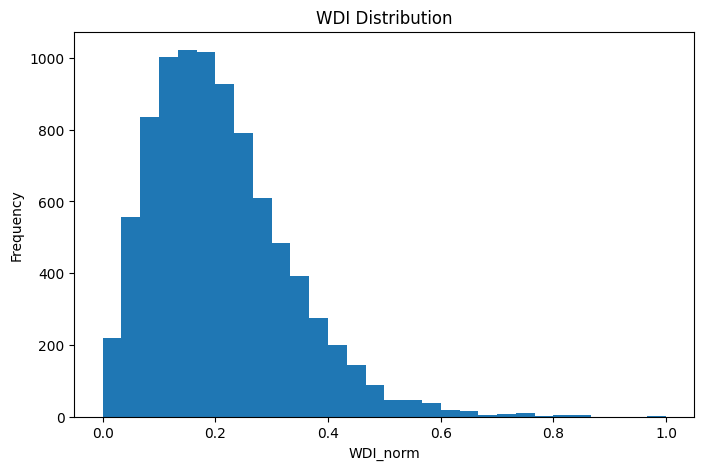

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["WDI_norm"], bins=30)

plt.title("WDI Distribution")
plt.xlabel("WDI_norm")
plt.ylabel("Frequency")

plt.show()

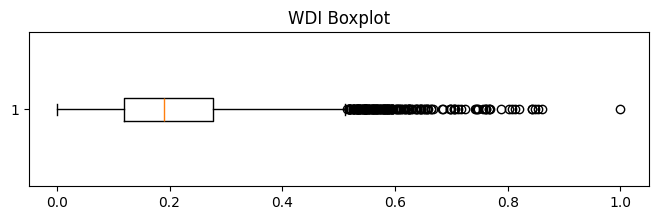

In [8]:
plt.figure(figsize=(8,2))

plt.boxplot(df["WDI_norm"], vert=False)

plt.title("WDI Boxplot")

plt.show()

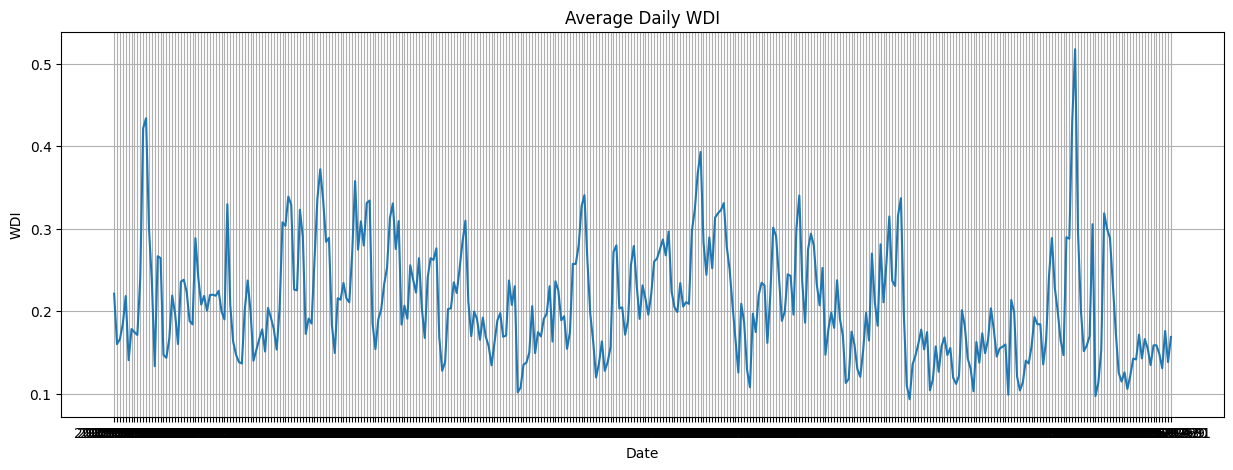

In [9]:
daily_wdi = (
    df.groupby("date")["WDI_norm"]
      .mean()
)

plt.figure(figsize=(15,5))

plt.plot(daily_wdi)

plt.title("Average Daily WDI")
plt.xlabel("Date")
plt.ylabel("WDI")

plt.grid(True)

plt.show()


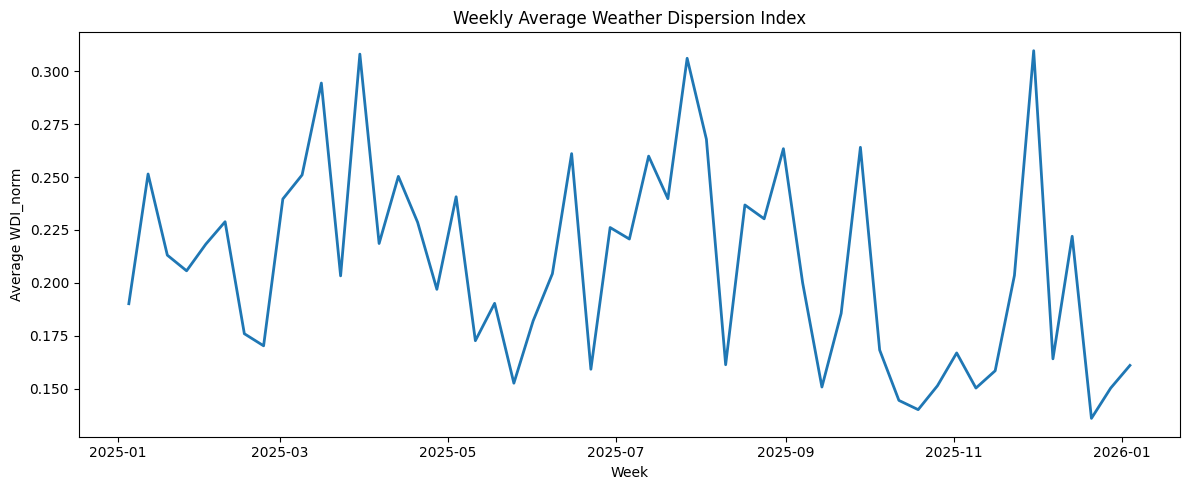

In [11]:
# Tạo cột datetime
df["datetime"] = pd.to_datetime(df["date"] + " " + df["hour"])

# Lấy trung bình theo tuần
weekly_wdi = df.groupby(pd.Grouper(key="datetime", freq="W"))["WDI_norm"].mean()

# Plot
plt.figure(figsize=(12,5))

plt.plot(weekly_wdi.index, weekly_wdi.values, linewidth=2)

plt.title("Weekly Average Weather Dispersion Index")
plt.xlabel("Week")
plt.ylabel("Average WDI_norm")

plt.tight_layout()
plt.show()

In [10]:
wdi_df = df[
    [
        "date",
        "hour",
        "WDI",
        "WDI_norm"
    ]
]

wdi_df.to_csv(
    "../../data/processed/weather/hcm_weather_wdi.csv",
    index=False
)

print("Saved successfully")

Saved successfully
